# 3–4 Linear Regression: predict a continuous outcome, then tame it with regularisation

Regression predicts a **continuous** number (here, a house price) rather than a class label. This notebook walks the full cvML pipeline on the Boston housing data, then introduces **regularisation** – the lever that stops a flexible model from overfitting.

> **Data note.** Boston is the classic regression demo, but scikit-learn's *built-in* `load_boston` is deprecated. We pull the same dataset from **openml** instead (`fetch_openml`) – this is also what Assignment 1 asks you to do.


## Regression is about predicting continuous outcomes rather than discrete class labels.
### Use linear regression to predict Boston housing prices. The variables can be described as:
1. CRIM per capita crime rate by town
1. ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
1. INDUS    proportion of non-retail business acres per town
1. CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
1. NOX      nitric oxides concentration (parts per 10 million)
1. RM       average number of rooms per dwelling
1. AGE      proportion of owner-occupied units built prior to 1940
1. DIS      weighted distances to five Boston employment centres
1. RAD      index of accessibility to radial highways
1. TAX      full-value property-tax rate per $10,000
1. PTRATIO  pupil-teacher ratio by town
1. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
1. LSTAT    % lower status of the population
1. MEDV     Median value of owner-occupied homes in $1000's


Scikit-learn includes some sample datasets. The Boston dataset is imported:


In [16]:
import numpy as np


In [17]:
from sklearn import datasets
from sklearn import metrics
from sklearn import model_selection
from sklearn import linear_model

In [18]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams.update({'font.size': 16})

In [19]:
rseed = np.random.seed(42)

In [20]:
# boston = datasets.load_boston()
from sklearn.datasets import fetch_openml
boston = fetch_openml(name="boston", version=1, as_frame=False)

The structure of `boston` is a Bunch:

- `DESCR` – a text description of the dataset
- `data` – the features, shape `(num_samples, num_features)`
- `feature_names` – the names of the columns
- `target` – the real-valued house prices, shape `(num_samples,)`
- `filename` – where scikit-learn cached the CSV


In [21]:
print(dir(boston))

['DESCR', 'categories', 'data', 'details', 'feature_names', 'frame', 'target', 'target_names', 'url']


In [22]:
print(boston.data.shape)

(506, 13)


There are 506 data points; each have 13 feature values:


In [41]:
print(boston.target.shape)

(506,)


Target inspection shows only a single target value (typical), i.e. label corresponding to the target value of housing price:


13 features:


In [24]:
print(boston.feature_names)

['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


Since earlier inspection of target values revealed that data is not categorized as classes, it is a regression problem:


In [25]:
print(np.unique(boston.target)) #aka ground truth data (but on whole dataset)

[ 5.   5.6  6.3  7.   7.2  7.4  7.5  8.1  8.3  8.4  8.5  8.7  8.8  9.5
  9.6  9.7 10.2 10.4 10.5 10.8 10.9 11.  11.3 11.5 11.7 11.8 11.9 12.
 12.1 12.3 12.5 12.6 12.7 12.8 13.  13.1 13.2 13.3 13.4 13.5 13.6 13.8
 13.9 14.  14.1 14.2 14.3 14.4 14.5 14.6 14.8 14.9 15.  15.1 15.2 15.3
 15.4 15.6 15.7 16.  16.1 16.2 16.3 16.4 16.5 16.6 16.7 16.8 17.  17.1
 17.2 17.3 17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2 18.3 18.4 18.5
 18.6 18.7 18.8 18.9 19.  19.1 19.2 19.3 19.4 19.5 19.6 19.7 19.8 19.9
 20.  20.1 20.2 20.3 20.4 20.5 20.6 20.7 20.8 20.9 21.  21.1 21.2 21.4
 21.5 21.6 21.7 21.8 21.9 22.  22.1 22.2 22.3 22.4 22.5 22.6 22.7 22.8
 22.9 23.  23.1 23.2 23.3 23.4 23.5 23.6 23.7 23.8 23.9 24.  24.1 24.2
 24.3 24.4 24.5 24.6 24.7 24.8 25.  25.1 25.2 25.3 26.2 26.4 26.5 26.6
 26.7 27.  27.1 27.5 27.9 28.  28.1 28.2 28.4 28.5 28.6 28.7 29.  29.1
 29.4 29.6 29.8 29.9 30.1 30.3 30.5 30.7 30.8 31.  31.1 31.2 31.5 31.6
 31.7 32.  32.2 32.4 32.5 32.7 32.9 33.  33.1 33.2 33.3 33.4 33.8 34.6
 34.7 3

Tackle problem using Linear Regression


Training the model


In [26]:
linreg = linear_model.LinearRegression()

### Before we regularise: the bias–variance trade-off

A model's total error splits into three parts (see the slides):

$$\underbrace{(\text{bias})^2}_{\text{wrong on average}} + \underbrace{\text{variance}}_{\text{jittery across training sets}} + \underbrace{\sigma^2}_{\text{irreducible noise}} = \text{total error}$$

- **Bias** – how wrong the model is *on average*. A straight line fitting a curve has high bias (it simply can't bend).
- **Variance** – how much the model's predictions jump around when you retrain on a different sample. A 100-degree polynomial fitting 20 points has high variance (it moulds itself to the noise).
- **Irreducible noise** $\sigma^2$ – the part no model can remove; it lives in the data, not the model.

You cannot lower both bias and variance with one knob for free – **that is the trade-off**. A more flexible model lowers bias (it can fit more shapes) but raises variance (it fits the noise too). A less flexible model does the reverse.

**Regularisation is the lever that nudges this balance.** It adds a penalty for big weights, so a flexible model is *held back* from chasing every wiggle of the training data. That raises bias a touch but lowers variance a lot – exactly the move you want when you're **overfitting** (high variance). We'll see the two flavours next: Ridge (L2) and Lasso (L1).

> 🧠 **Quick quiz (we revisit this in `8_Trees`):**
> 1. A model with **low bias and high variance** – is it underfitting or overfitting?
> 2. Which does **regularisation** fight – bias or variance? Which does it cost you?
> 3. If your training R² is 0.99 but your test R² is 0.20, which error term is dominating?


### How about with regularisation? Which works best on test data?

Plain `LinearRegression` fits the training data with no constraint on the weights, so a flexible model can chase the noise. **Regularisation** adds a penalty that keeps the weights small – trading a little bias for a lot of variance.

### 1. Simplest example: regularisation is one swapped line

The whole idea in one swap – `Ridge()` vs `Lasso()` vs plain `LinearRegression()`, same `.fit()` / `.predict()` afterwards:

```python
linreg = linear_model.Ridge()    # L2: shrink all weights, keep them all
linreg = linear_model.Lasso()    # L1: shrink, and zero some weights out
linreg = linear_model.LinearRegression()  # none: no penalty at all
```

### End of simplest example

That is it – the only thing that changes is the model class; everything you already know (fit → predict → score) still applies. Now we run all three on the Boston data and compare.


### 🧠 Quick check – bias, variance, and the L1 vs L2 swap

1. The trade-off says you cannot lower bias and variance with one knob for free. Give the bias-variance decomposition of total error (three terms), and say which term **no model** can ever remove.
2. You swap `LinearRegression()` for `Ridge()` (L2) or `Lasso()` (L1). Both add a penalty that shrinks the weights. Which one can **zero out** a weight entirely (feature selection as a side effect), and why does its constraint *shape* make that happen?
3. Turn the regularization strength knob up (larger penalty). What happens to **bias** and **variance** as you push it too far, and which direction is the overfit / underfit end?
4. A classmate tunes a Ridge model and finds train $R^2 = 0.98$ but test $R^2 = 0.55$. Name the symptom and say which way to turn the L2 penalty to fix it.

<details><summary>Answers (click to reveal)</summary>

1. Total error $= \underbrace{(\text{bias})^2}_{\text{wrong on average}} + \underbrace{\text{variance}}_{\text{jittery across training sets}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$. The **irreducible noise $\sigma^2$** lives in the data, not the model, so no model can remove it – you can only drive bias and variance down to it.
2. **Lasso (L1)** can zero weights out. Its constraint region is a **diamond** ($\|w\|_1 \le t$), and the loss contours tend to touch a diamond **corner** where one coordinate is exactly zero → that feature is dropped. Ridge's constraint is a **circle** ($\|w\|_2 \le t$), touched on a curved side where both weights stay non-zero, so Ridge shrinks but rarely selects.
3. Pushing the penalty up shrinks the weights harder: **variance falls** (less wiggly fit) but **bias rises** (the model cannot bend to the signal). Too small a penalty → low bias, high variance → **overfit**; too large a penalty → high bias, low variance → **underfit**.
4. Train ≫ test with a large gap is **overfitting** (high variance). Raise the L2 penalty (larger `alpha` in `Ridge`) to shrink the weights and trade a little bias for lower variance until the gap closes.

</details>

Split the data into training and test sets 80:20.


In [27]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    boston.data, boston.target, test_size=0.2, random_state=42
)

Hey what about creating a Cross Validation (CV) set? No, keep it simple for now.


`train` function is called `fit`, but mostly behaves the same as in OpenCV's `train`:


In [ ]:
linreg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.11, 0.03, 0.04,...,-0.92, 0.01,-0.51]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[3482.49,1589.14, 582.91,..., 10.19, 4.97, 1.12]"


Testing the model on seen data (how well your input is represented by the model)y_pred


In [29]:
y_pred = linreg.predict(X_train)
metrics.mean_squared_error(y_train, y_pred)

21.641412753226312

The `score` method of the `linreg` object returns the coefficient of determination (R-squared) for training:


In [30]:
linreg.score(X_train, y_train)

0.7508856358979673

### Testing the model on seen or unseen data


quick hack to make it test on training (seen) data (don't do this IRL):


In [31]:
# X_test = X_train
# y_test = y_train

Predict on unseen :)


In [32]:
y_pred = linreg.predict(X_test)
# MSE gives us an idea of the `generalisation performance` of the model:
print(metrics.mean_squared_error(y_test, y_pred))

24.291119474973485


The `score` method of the `linreg` object's default metric is coefficient of determination (R-squared):


In [33]:
print(linreg.score(X_test, y_test))
# The same thing but explicit
print(metrics.r2_score(y_test,y_pred))

0.6687594935356325
0.6687594935356325


Plot the data to help visualize the model performance:


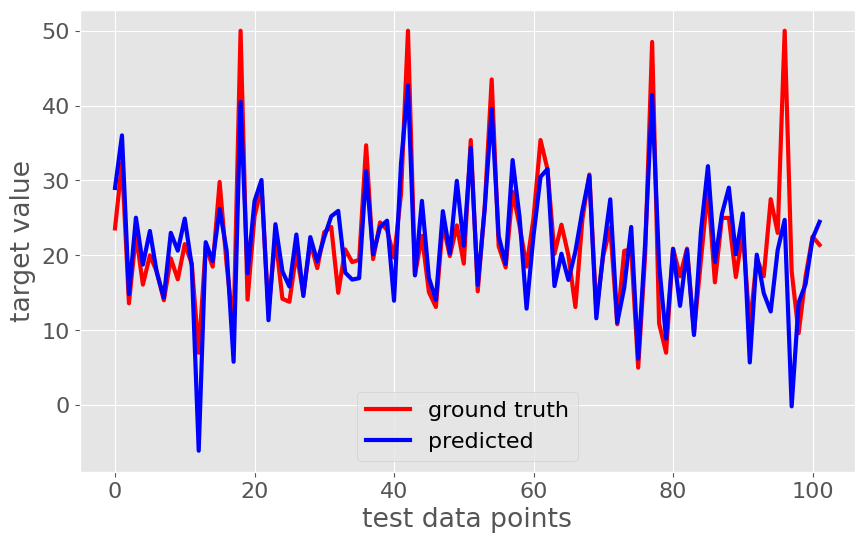

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, 'r', linewidth=3, label='ground truth')
plt.plot(y_pred, 'b', linewidth=3, label='predicted')
plt.legend(loc='best')
plt.xlabel('test data points')
plt.ylabel('target value')
plt.show()

Ground truth housing prices for all test samples in blue and predicted housing prices in red.What kind of prices causes the model to have increased error (on training and test data)?


Formalize the amount of variance in the data that we were able to explain by calculating R-squared:


Text(0, 0.5, 'predicted')

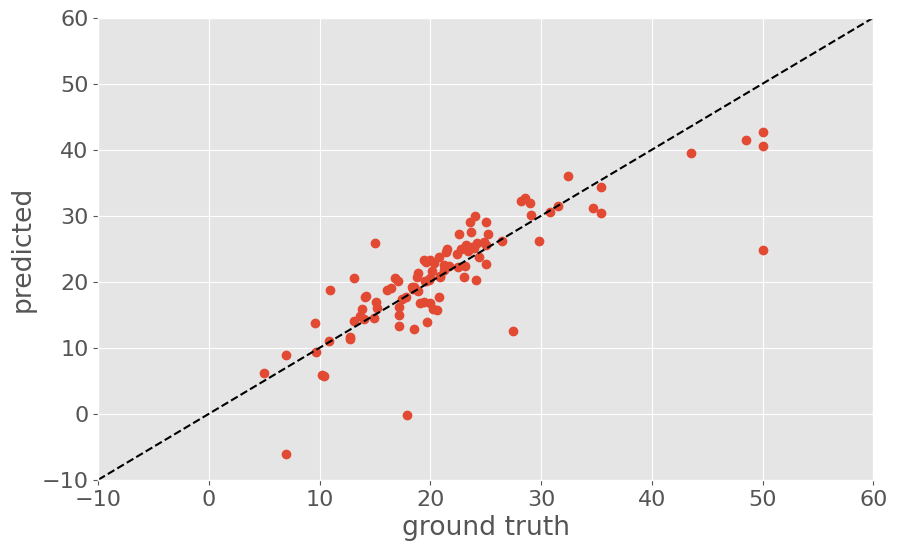

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, y_pred, 'o')
plt.plot([-10, 60], [-10, 60], 'k--')
plt.axis([-10, 60, -10, 60])
plt.xlabel('ground truth')
plt.ylabel('predicted')

## 🔁 Visual appendix

Self-contained visuals – each runs on its own data. Added to make the maths/algorithms in this lecture visible. But first check out what is meant by a "diamond"

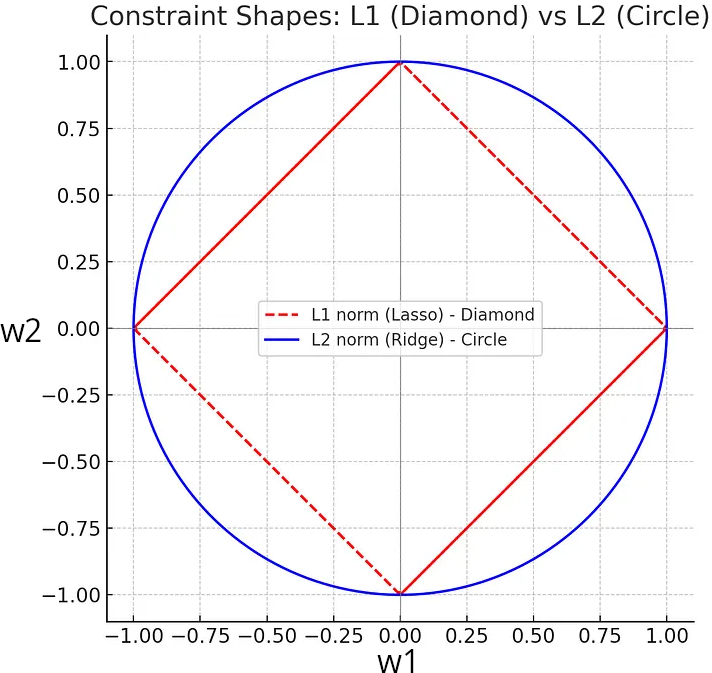

source: https://medium.com/@mohammedsaimquadri/mastering-regularization-in-linear-regression-l1-l2-elastic-net-e6ed2aea2b3b

### Why Lasso zeroes weights and Ridge only shrinks them – the geometry

Regularisation adds a **penalty** that says *"don't let the weights grow too big."* The penalty defines a **constraint region** the weights must live inside. The model then picks the point in that region with the lowest loss (the blue contours are lines of equal loss; the unregularised optimum $w^*$ – the weights we'd pick with *no* penalty – sits at their centre).

Here $w$ is the weight vector, $t$ is the **penalty budget** (how big the region is – smaller $t$ = stronger regularisation), and $w^*$ is the unconstrained best fit:

| | Ridge (L2): $\|w\|_2^2 \le t$ | Lasso (L1): $\|w\|_1 \le t$ |
| - | - | - |
| **Constraint shape** | a **circle** | a **diamond** |
| **Where the loss contour first touches it** | on a **curved edge** → both weights shrink | on a **corner** (an axis) → one weight = **0** |
| **Effect** | shrinks all weights, rarely exactly zero | zeroes some weights → **feature selection** |

The key intuition: a diamond's corners lie *on the axes*, so the best point inside a diamond very often has one coordinate exactly zero. A circle has no corners, so the contact point almost never lands on an axis. **That single geometric difference is why Lasso does feature selection and Ridge does not.**


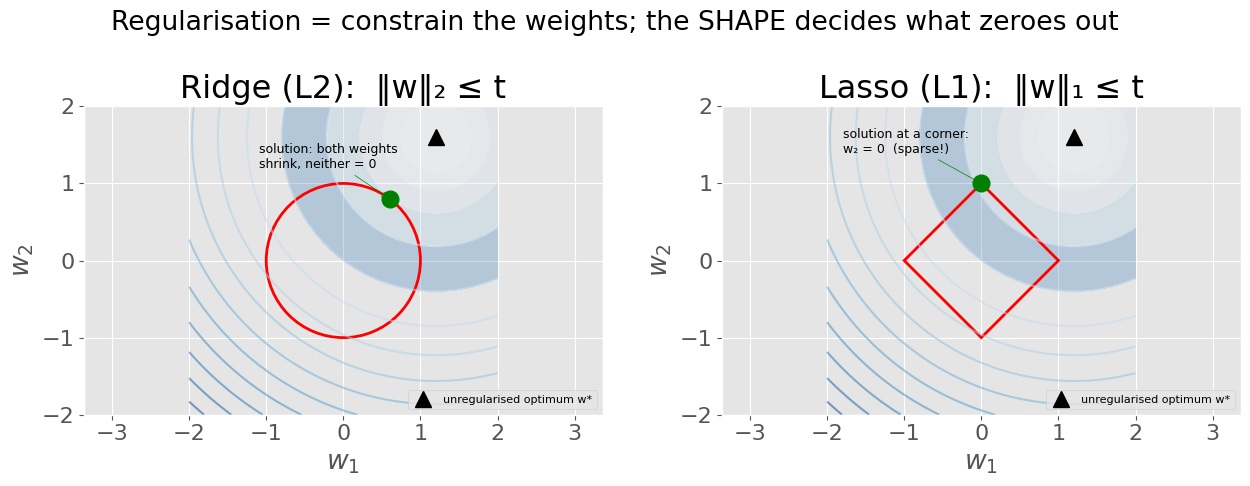

In [36]:
# The constraint shape decides whether weights zero out.
import numpy as np, matplotlib.pyplot as plt

w1, w2 = np.meshgrid(np.linspace(-2, 2, 150), np.linspace(-2, 2, 150))
# loss = squared distance to the unregularised optimum w* = (1.2, 1.6). Blue contours = equal loss.
loss = (w1 - 1.2)**2 + (w2 - 1.6)**2

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for axi, (shape, name) in zip(ax, [("circle", "Ridge (L2):  ‖w‖₂ ≤ t"),
                                   ("diamond", "Lasso (L1):  ‖w‖₁ ≤ t")]):
    axi.contour(w1, w2, loss, levels=12, cmap='Blues', alpha=.5)
    axi.contourf(w1, w2, loss, levels=[0, 0.2, 0.5, 1, 2, 4], cmap='Blues', alpha=.25)
    if shape == "circle":
        axi.add_patch(plt.Circle((0, 0), 1, fill=False, color='red', lw=2))
        d = np.array([1.2, 1.6]); p = d / np.linalg.norm(d)        # nearest point on circle to w*
        axi.plot(p[0], p[1], 'go', ms=12, zorder=5)
        axi.annotate('solution: both weights\nshrink, neither = 0', xy=tuple(p),
                     xytext=(p[0]-1.7, p[1]+0.4), fontsize=9,
                     arrowprops=dict(arrowstyle='->', color='green'))
    else:
        axi.add_patch(plt.Polygon([(1,0),(0,1),(-1,0),(0,-1)], fill=False, color='red', lw=2))
        axi.plot(0, 1, 'go', ms=12, zorder=5)                       # corner hit -> w2 = 0
        axi.annotate('solution at a corner:\nw₂ = 0  (sparse!)', xy=(0, 1),
                     xytext=(-1.8, 1.4), fontsize=9,
                     arrowprops=dict(arrowstyle='->', color='green'))
    axi.plot(1.2, 1.6, 'k^', ms=11, label='unregularised optimum w*')
    axi.set_title(name); axi.set_xlabel(r'$w_1$'); axi.set_ylabel(r'$w_2$')
    axi.axis('equal'); axi.legend(loc='lower right', fontsize=8)
plt.suptitle('Regularisation = constrain the weights; the SHAPE decides what zeroes out')
plt.tight_layout(); plt.show()


### 🧠 Quick quiz

1. Why does Ridge almost **never** produce an exactly-zero weight, even with huge `alpha`?
2. You have 200 features but only 10 matter. Which regulariser do you reach for, and what does its coefficient vector look like afterwards?
3. Set `alpha = 0` in both. Why do Ridge and Lasso then give the *same* answer as plain `LinearRegression`?
4. **(Exam-style compare)** Ridge shrinks weights smoothly; Lasso can zero them out. Relate this difference to the *shape* of each penalty's constraint region (circle vs diamond), and state which one gives you a built-in feature selector.

<details><summary>Answers (click to reveal)</summary>

1. Ridge's L2 penalty $\alpha\sum_j w_j^2$ has gradient $2\alpha w_j$, which shrinks each weight toward zero but only *asymptotically* – the pull gets weaker the closer $w_j$ is to zero, so a weight that the data wants to keep never quite reaches exactly 0. Only an infinite `alpha` would force it there.
2. **Lasso** – the L1 diamond's corners lie on the axes, so the optimum lands on a corner and sets the irrelevant weights to exactly 0. The coefficient vector is **sparse**: ~10 non-zero entries and ~190 exact zeros, which is its built-in feature selection.
3. With `alpha = 0` the penalty term vanishes from both costs, so both reduce to plain least squares $(y-Xw)^\top(y-Xw)$ – the same objective `LinearRegression` solves – hence the same solution.
4. Ridge's constraint is a **circle** ($|w|_2 \le t$); the loss contour kisses it on the curved edge, so weights shrink but stay non-zero. Lasso's constraint is a **diamond** ($|w|_1 \le t$); its corners poke out along the axes, so the kiss lands on a corner and one weight becomes exactly 0. The diamond's axis-corners are what make Lasso a **feature selector**; the circle's smooth edge is what makes Ridge a **shrinker**.

</details>
